# Котик Александр БПМ 253. Анализ датасета 'super store dataset' на kaggle

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"C:\Users\NyaxyS\Downloads\superstore\Sample - Superstore.csv", encoding='latin1').set_index('Row ID')

### Этот датасет содержит записи о транзакциях продаж для розничного магазина. Он включает сведения о заказах клиентов, информацию о доставке, категории товаров и финансовые показатели, такие как продажи, скидки и прибыль.

In [3]:
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
Row ID,,,,,,,,,,,,,,,,,,,,
1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### Проверим на пустые значения и уберем дупликаты

In [4]:
df.shape

(9994, 20)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9994 entries, 1 to 9994
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9994 non-null   object 
 1   Order Date     9994 non-null   object 
 2   Ship Date      9994 non-null   object 
 3   Ship Mode      9994 non-null   object 
 4   Customer ID    9994 non-null   object 
 5   Customer Name  9994 non-null   object 
 6   Segment        9994 non-null   object 
 7   Country        9994 non-null   object 
 8   City           9994 non-null   object 
 9   State          9994 non-null   object 
 10  Postal Code    9994 non-null   int64  
 11  Region         9994 non-null   object 
 12  Product ID     9994 non-null   object 
 13  Category       9994 non-null   object 
 14  Sub-Category   9994 non-null   object 
 15  Product Name   9994 non-null   object 
 16  Sales          9994 non-null   float64
 17  Quantity       9994 non-null   int64  
 18  Discount     

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df['Country'].unique()

array(['United States'], dtype=object)

### Так как заказы происходят только внутри одной страны, можно удалить эту колонку

In [8]:
df['Customer ID'].nunique() == df['Customer Name'].nunique()

True

In [9]:
df['Product ID'].nunique()

1862

In [10]:
df['Product Name'].nunique()

1850

### Мы видим что значений названий для товаров больше в абсолютных значениях чем ID, но так как мы будем использовать ID это не критично

### Переведем даты в правильный формат

In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'], infer_datetime_format=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], infer_datetime_format=True)


### Убираем ненужные колонки из таблицы

In [12]:
df.drop(columns=['Country', 'Postal Code','Product Name','Customer Name'], inplace= True)

In [13]:
yearly = df.groupby(df['Order Date'].dt.year)[['Profit', 'Sales','Discount']].agg({'Profit':'sum', 'Sales':'sum', 'Discount':'mean'})

### Посмотрим зависимость ключевых атрибутов по годам

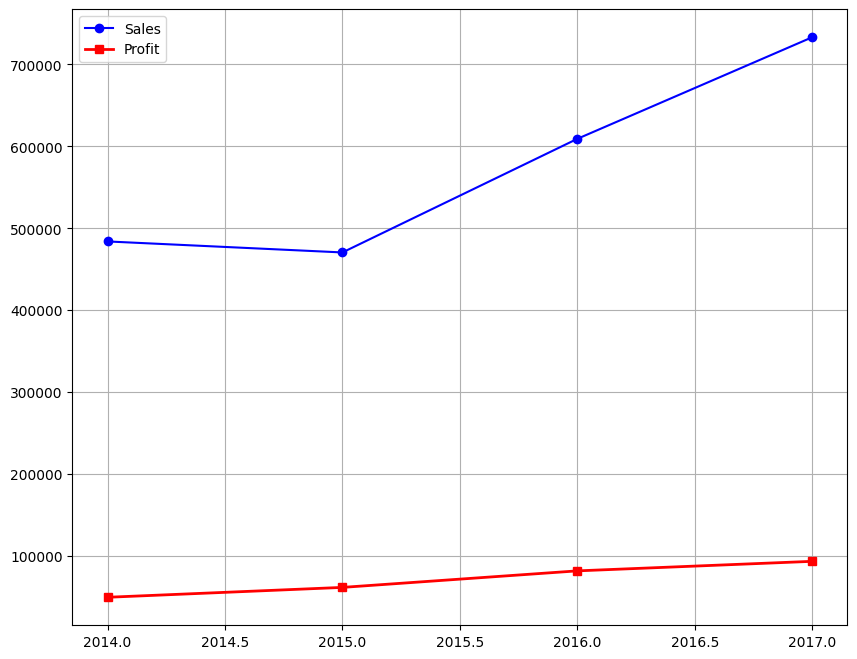

In [14]:
plt.figure(figsize = (10, 8))

plt.plot(yearly.index, yearly['Sales'], 'b-o', label = 'Sales')
plt.plot(yearly.index, yearly['Profit'],'r-s', label = 'Profit', linewidth=2)
plt.legend()
plt.grid()
plt.show()

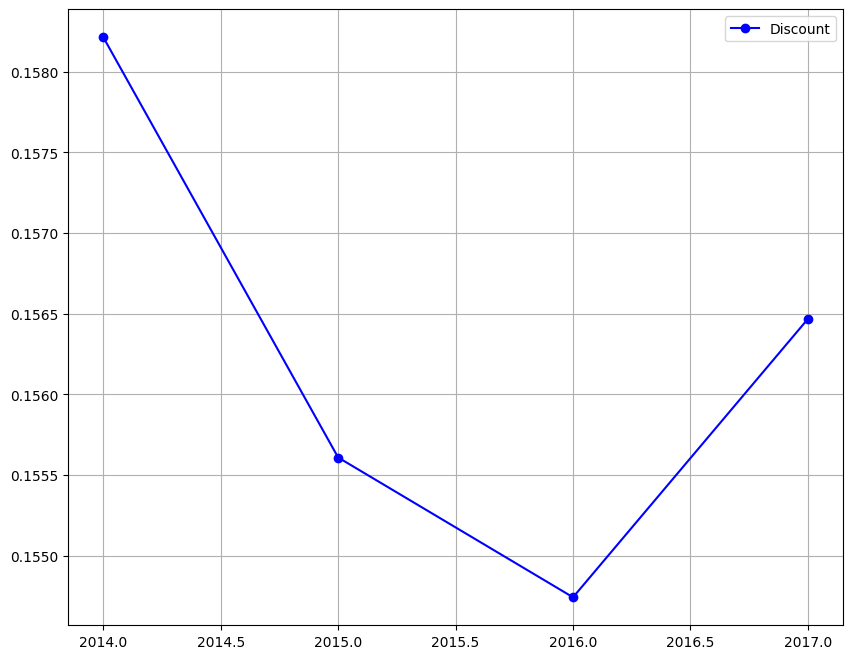

In [15]:
plt.figure(figsize = (10, 8))

plt.plot(yearly.index, yearly['Discount'], 'b-o', label = 'Discount')
plt.legend()
plt.grid()
plt.show()

### Разница в скиках в среднем не более чем 0.5%, будем считать это допустимым для анализа 

In [16]:
df['Discount'] = df['Discount']*100

In [17]:
df.groupby('Discount')['Profit'].mean()

Discount
0.0      66.900292
10.0     96.055074
15.0     27.288298
20.0     24.702572
30.0    -45.828401
32.0    -88.560656
40.0   -111.927429
45.0   -226.646464
50.0   -310.703456
60.0    -43.077212
70.0    -95.874060
80.0   -101.796797
Name: Profit, dtype: float64

### Мы видим что скидки >= 30% убыточны для нашей компании, наша задача оценить потери и оптимизировать их

In [18]:
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,City,State,Region,Product ID,Category,Sub-Category,Sales,Quantity,Discount,Profit
Row ID,,,,,,,,,,,,,,,,
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Consumer,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,261.9600,2,0.0,41.9136
2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Consumer,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,731.9400,3,0.0,219.5820
3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Corporate,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,14.6200,2,0.0,6.8714
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Consumer,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,957.5775,5,45.0,-383.0310
5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Consumer,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,22.3680,2,20.0,2.5164


### Посмотрим зависимость ключевых атрибутов по месяцам

In [19]:
montly = df[df['Discount']>=30].groupby(df['Order Date'].dt.month).agg({'Profit':'sum', 'Sales':'sum', 'Discount':'mean'})
montly_general = df[df['Discount']<30].groupby(df['Order Date'].dt.month).agg({'Profit':'sum', 'Sales':'sum'})

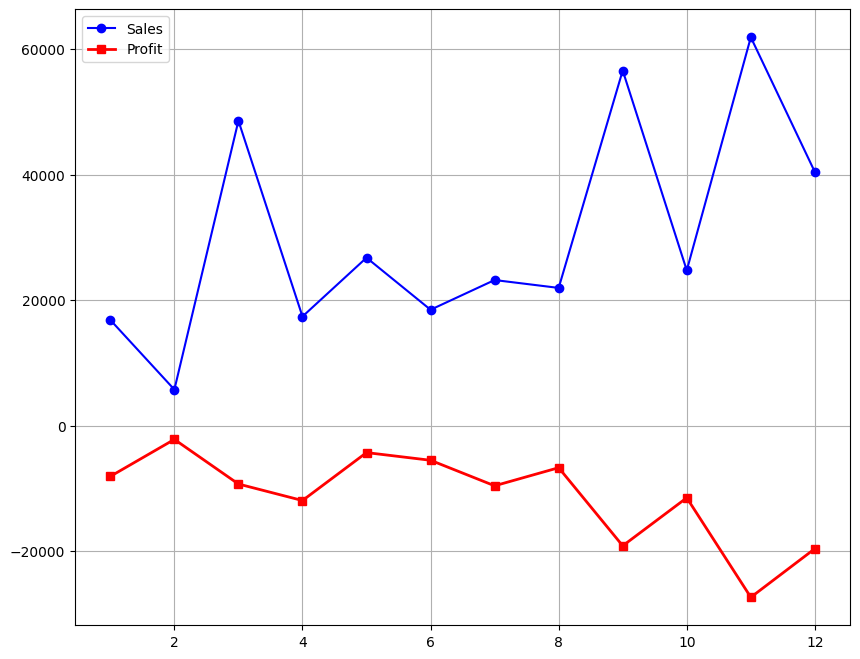

In [20]:
plt.figure(figsize = (10, 8))

plt.plot(montly.index, montly['Sales'], 'b-o', label = 'Sales')
plt.plot(montly.index, montly['Profit'],'r-s', label = 'Profit', linewidth=2)
plt.legend()
plt.xlabel = 'month'
plt.grid()
plt.show()

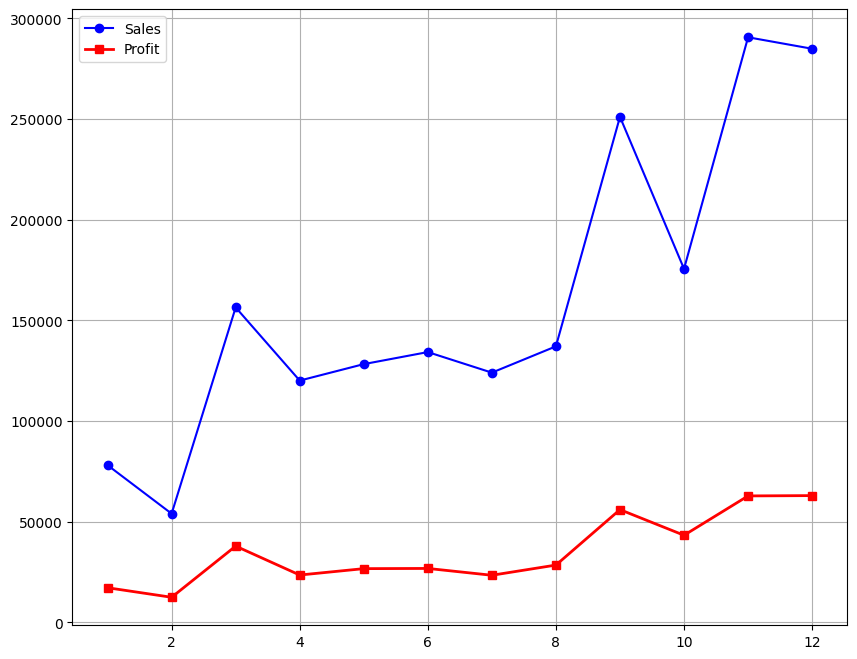

In [21]:
plt.figure(figsize = (10, 8))

plt.plot(montly_general.index, montly_general['Sales'], 'b-o', label = 'Sales')
plt.plot(montly_general.index, montly_general['Profit'],'r-s', label = 'Profit', linewidth=2)
plt.legend()
plt.grid()
plt.show()

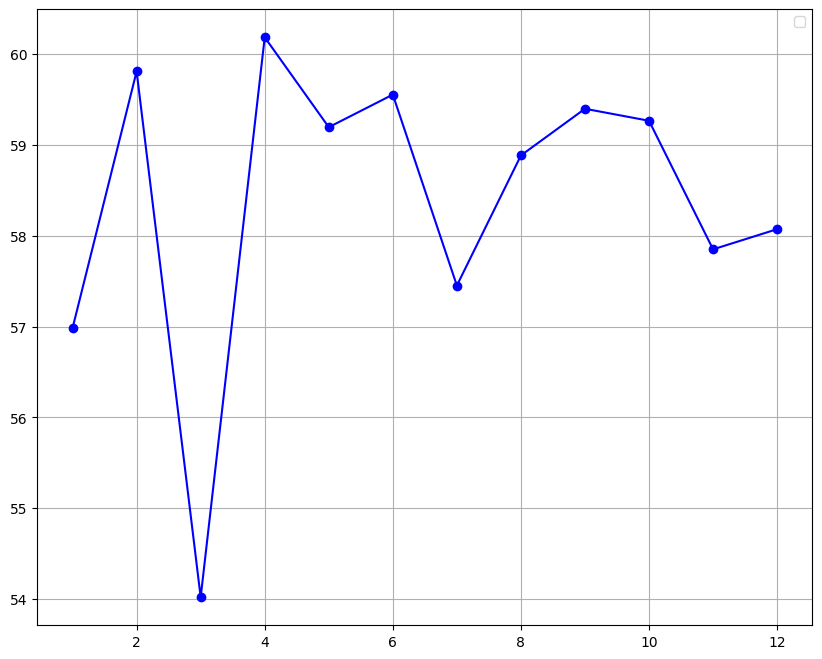

In [22]:
plt.figure(figsize = (10, 8))

plt.plot(montly.index, montly['Discount'], 'b-o')
plt.legend()
plt.grid()
plt.show()

### Посмотрим отдельно на большие скидки по разным категориям клиентов

In [23]:
Segmentation = df[df['Discount']>=30].groupby(df['Segment']).agg({'Profit':'sum', 'Sales':'sum', 'Discount':'mean'})


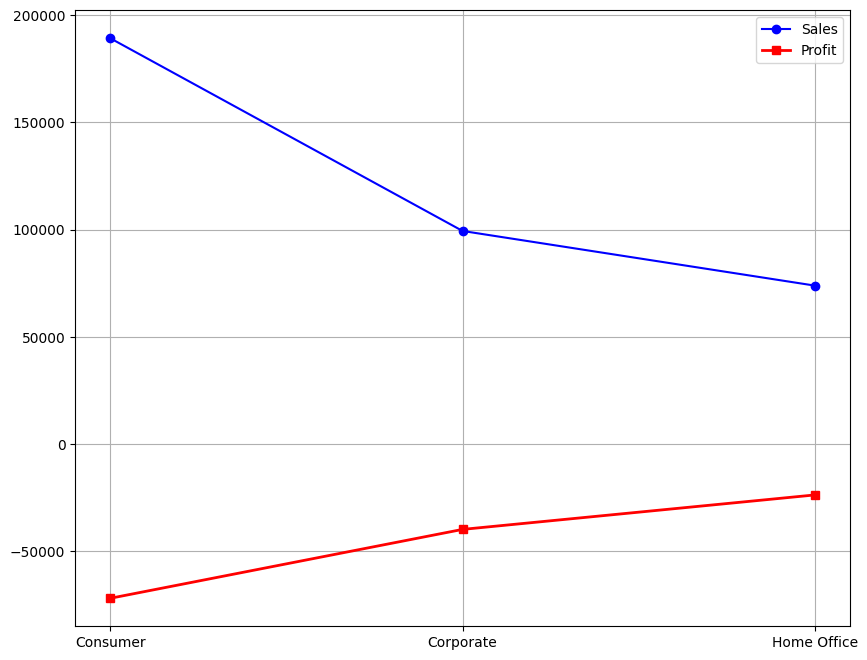

In [24]:
plt.figure(figsize = (10, 8))

plt.plot(Segmentation.index, Segmentation['Sales'], 'b-o', label = 'Sales')
plt.plot(Segmentation.index, Segmentation['Profit'],'r-s', label = 'Profit', linewidth=2)

plt.legend()
plt.grid()
plt.show()

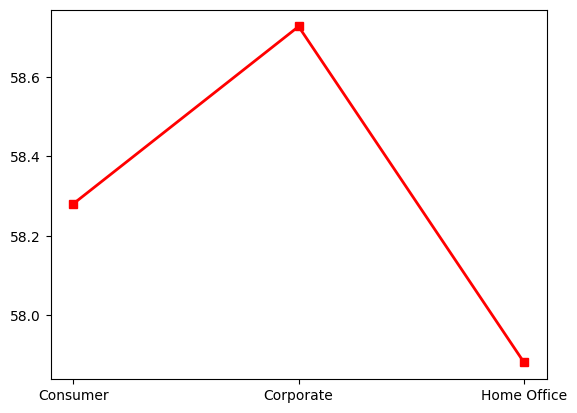

In [25]:
plt.plot(Segmentation.index, Segmentation['Discount'],'r-s', label = 'Discount', linewidth=2)


### Средние показатели скидки для разных сегментов, в случае если скидка >=30% значительно не отличаются

### Проверим как работает скидка на первый заказ

In [26]:
df_sorted = df.sort_values('Order Date')
first_orders = df_sorted.groupby('Customer ID')['Order Date'].rank(method='first')==1

big_disc_customers = df[(df['Discount']>=30)& first_orders & (df['Profit']<=0)]['Customer ID'].unique()

In [27]:
big_disc_corp = df[(df['Segment'] == 'Corporate') & (df['Customer ID'].isin(big_disc_customers))]
big_disc_cuns = df[(df['Segment'] == 'Consumer') & (df['Customer ID'].isin(big_disc_customers))]
big_disc_home = df[(df['Segment'] == 'Home Office') & (df['Customer ID'].isin(big_disc_customers))]

In [28]:
big_disc_corp['Profit'].mean()/df[df['Segment']=='Corporate']['Profit'].mean()

np.float64(0.04134793234844976)

In [29]:
big_disc_cuns['Profit'].mean()/df[df['Segment']=='Consumer']['Profit'].mean()

np.float64(0.3123459291730915)

In [30]:
big_disc_home['Profit'].mean()

np.float64(-1.5807548611111133)

In [31]:
df[df['Segment']=='Home Office']['Profit'].mean()

np.float64(33.844409259259265)

### Вывод, скидка >= 30% на первый заказ плохо себя показывает на дистанции, маленькие показатели для корпораций и для обычных пользователей в сравнении со средними, а для домашних офиссов выходят в минус 

### Проверим как работает скидка не на первый заказ для покупателя

In [32]:
big_disc_customers2 = df[(df['Discount']>=30) & (~first_orders)]['Customer ID'].unique()

In [33]:
big_disc_corp2 = df[(df['Customer ID'].isin(big_disc_customers2)) & (df['Segment'] == 'Corporate') ]
big_disc_cuns2 = df[(df['Segment'] == 'Consumer') & (df['Customer ID'].isin(big_disc_customers2))]
big_disc_home2= df[(df['Segment'] == 'Home Office') & (df['Customer ID'].isin(big_disc_customers2))]

In [34]:
big_disc_corp2['Profit'].mean()/df[df['Segment']=='Corporate']['Profit'].mean()

np.float64(0.7927714163832177)

In [35]:
big_disc_cuns2['Profit'].mean()/df[df['Segment']=='Consumer']['Profit'].mean()

np.float64(0.6987316202266842)

In [36]:
big_disc_home2['Profit'].mean()/df[df['Segment']=='Home Office']['Profit'].mean()

np.float64(0.7557693795981624)

### Скидка 30% для постоянных клиентов показывает себя удовлетворительно, поэтому в первую очередь нужно проанализировать скидку конкретно на первый заказ

In [37]:
df.groupby('Customer ID')['Order Date'].min().dt.year.value_counts().sort_index()

Order Date
2014    595
2015    136
2016     51
2017     11
Name: count, dtype: int64

### Мы видим, что количество новых клиентов в 2016 и 2017 сильно меньше по сравнению с 2014 и 2015 годами. Это дает понимание почему большие скидки на первые заказы приносили не такой большой плюс, как скидки для постоянных клиентов. Для когортного анализа мы будем брать толкьо первые два года

In [38]:
first_orders_all = df.groupby('Customer ID')['Order Date'].min()
first_orders_all = first_orders_all.reset_index()

In [39]:
customers_2014_2015 = first_orders_all[(first_orders_all['Order Date'].dt.year == 2014)| (first_orders_all['Order Date'].dt.year == 2015)]
customers_2014_2015.head()

,Customer ID,Order Date
0,AA-10315,2014-03-31
1,AA-10375,2014-04-21
2,AA-10480,2014-05-04
3,AA-10645,2014-06-22
4,AB-10015,2014-02-18


### Наша задача провести когортный анализ для определения оптимальной скидки на первый заказ для каждой категории покупателей, для этого я добавлю новую колонку, показывающую скидку на первый заказ для этого покупателя

In [40]:
df['Discount'].unique()

array([ 0., 45., 20., 80., 30., 50., 70., 60., 32., 10., 40., 15.])

In [41]:
s = [0, 10, 20, 30, 40, 101]

labels = ['0-10%', '11-20%', '21-30%', '30-40%', '>=41%']



In [42]:
df_filtered = df[df['Customer ID'].isin(customers_2014_2015['Customer ID'])]

In [43]:
df_filtered_sorted = df_filtered.sort_values(['Customer ID', 'Order Date'])

In [44]:
first_orders_filtered = df_filtered_sorted.groupby('Customer ID').first().reset_index()
first_orders_filtered.head()

,Customer ID,Order ID,Order Date,Ship Date,Ship Mode,Segment,City,State,Region,Product ID,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,AA-10315,CA-2014-128055,2014-03-31,2014-04-05,Standard Class,Consumer,San Francisco,California,West,OFF-BI-10004390,Office Supplies,Binders,673.568,2,20.0,252.5880
1,AA-10375,CA-2014-158064,2014-04-21,2014-04-25,Standard Class,Consumer,Los Angeles,California,West,OFF-BI-10002976,Office Supplies,Binders,16.520,5,20.0,5.5755
2,AA-10480,CA-2014-155271,2014-05-04,2014-05-04,Same Day,Consumer,Middletown,Connecticut,East,FUR-FU-10001473,Furniture,Furnishings,27.460,2,0.0,9.8856
3,AA-10645,CA-2014-154963,2014-06-22,2014-06-27,Standard Class,Consumer,Chester,Pennsylvania,East,FUR-CH-10004698,Furniture,Chairs,170.058,3,30.0,-4.8588
4,AB-10015,CA-2014-152905,2014-02-18,2014-02-24,Standard Class,Consumer,Arlington,Texas,Central,OFF-ST-10000321,Office Supplies,Storage,12.624,2,20.0,-2.5248


In [45]:
first_orders_filtered['Discount Group'] = pd.cut(first_orders_filtered['Discount'], bins= s, labels=labels, include_lowest=True )

In [46]:
df_w_groups = pd.merge(df_filtered, first_orders_filtered[['Customer ID', 'Discount Group']], on='Customer ID', how ='left')

In [47]:
df_w_groups['month'] = df_w_groups['Order Date'].dt.month

In [48]:
df_w_groups.head()  

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,City,State,Region,Product ID,Category,Sub-Category,Sales,Quantity,Discount,Profit,Discount Group,month
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Consumer,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,261.9600,2,0.0,41.9136,>=41%,11
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Consumer,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,731.9400,3,0.0,219.5820,>=41%,11
2,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Consumer,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,957.5775,5,45.0,-383.0310,>=41%,10
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Consumer,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,22.3680,2,20.0,2.5164,>=41%,10
4,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Consumer,Los Angeles,California,West,FUR-FU-10001487,Furniture,Furnishings,48.8600,7,0.0,14.1694,0-10%,6


In [49]:
df_w_groups['year'] = df_w_groups['Order Date'].dt.year

### Для когортного анализа добавим в таблицу количество месяцев которое отображает сколько клиент сотрудничает с нами

In [50]:
first_orders_filtered_dates = first_orders_filtered[['Customer ID', 'Order Date']].copy()

In [51]:
first_orders_filtered_dates.rename(columns={'Order Date' : 'First Order Date'}, inplace=True)

In [52]:
df_w_groups = df_w_groups.merge(first_orders_filtered_dates, on = 'Customer ID', how = 'left')

In [53]:
df_w_groups['days_diff'] = (df_w_groups['Order Date'] - df_w_groups['First Order Date']).dt.days


In [54]:
df_w_groups['month lifetime'] = df_w_groups['days_diff']//30 + 1

### Разделим пользователей на категории

In [55]:
corporates_2014_2015 = df_w_groups[df_w_groups['Segment'] == 'Corporate']
consumers_2014_2015 = df_w_groups[df_w_groups['Segment'] == 'Consumer']
home_office_2014_2015 = df_w_groups[df_w_groups['Segment'] == 'Home Office']

In [56]:
df_w_groups.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,City,State,Region,Product ID,...,Sales,Quantity,Discount,Profit,Discount Group,month,year,First Order Date,days_diff,month lifetime
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Consumer,Henderson,Kentucky,South,FUR-BO-10001798,...,261.9600,2,0.0,41.9136,>=41%,11,2016,2015-10-15,390,14
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Consumer,Henderson,Kentucky,South,FUR-CH-10000454,...,731.9400,3,0.0,219.5820,>=41%,11,2016,2015-10-15,390,14
2,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Consumer,Fort Lauderdale,Florida,South,FUR-TA-10000577,...,957.5775,5,45.0,-383.0310,>=41%,10,2015,2015-10-11,0,1
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Consumer,Fort Lauderdale,Florida,South,OFF-ST-10000760,...,22.3680,2,20.0,2.5164,>=41%,10,2015,2015-10-11,0,1
4,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Consumer,Los Angeles,California,West,FUR-FU-10001487,...,48.8600,7,0.0,14.1694,0-10%,6,2014,2014-06-09,0,1


### Непосредственно когортный анализ

In [57]:
cohort_analysis = df_w_groups.groupby(['Discount Group', 'month lifetime']).agg({'Profit':'sum', 'Customer ID':'nunique', 'Sales':'sum'}).reset_index()
cohort_analysis.head()

,Discount Group,month lifetime,Profit,Customer ID,Sales
0,0-10%,1,45885.0320,357,200364.2430
1,0-10%,2,1623.9439,24,8466.2450
2,0-10%,3,608.1952,28,5705.9820
3,0-10%,4,2000.1653,28,13512.9760
4,0-10%,5,-760.9762,27,14488.7395


In [58]:
cohort_analysis_corp = corporates_2014_2015.groupby(['Discount Group', 'month lifetime']).agg({'Profit':'sum', 'Customer ID':'nunique', 'Sales':'sum'}).reset_index()
cohort_analysis_cons = consumers_2014_2015.groupby(['Discount Group', 'month lifetime']).agg({'Profit':'sum', 'Customer ID':'nunique', 'Sales':'sum'}).reset_index()
cohort_analysis_office = home_office_2014_2015.groupby(['Discount Group', 'month lifetime']).agg({'Profit':'sum', 'Customer ID':'nunique', 'Sales':'sum'}).reset_index()


### Добавим накопительную сумму дохода для каждой категории скидок на первый заказ

In [59]:
cohort_analysis_corp['cumulative profit'] = cohort_analysis_corp.groupby('Discount Group')['Profit'].cumsum()
cohort_analysis_office['cumulative profit'] = cohort_analysis_office.groupby('Discount Group')['Profit'].cumsum()
cohort_analysis_cons['cumulative profit'] = cohort_analysis_cons.groupby('Discount Group')['Profit'].cumsum()

In [60]:
cohort_analysis_corp.head()

,Discount Group,month lifetime,Profit,Customer ID,Sales,cumulative profit
0,0-10%,1,12629.8214,115,53003.3680,12629.8214
1,0-10%,2,656.9089,8,3024.6260,13286.7303
2,0-10%,3,45.0054,3,983.4520,13331.7357
3,0-10%,4,691.9381,13,5263.6660,14023.6738
4,0-10%,5,-847.9460,9,9721.5575,13175.7278


In [61]:
cohort_analysis_office.head()

,Discount Group,month lifetime,Profit,Customer ID,Sales,cumulative profit
0,0-10%,1,8676.9631,71,35969.395,8676.9631
1,0-10%,2,568.5608,4,2912.592,9245.5239
2,0-10%,3,67.1297,8,919.948,9312.6536
3,0-10%,4,983.6281,4,3925.364,10296.2817
4,0-10%,5,140.0962,5,1508.110,10436.3779


In [62]:
cohort_analysis_cons.head()

,Discount Group,month lifetime,Profit,Customer ID,Sales,cumulative profit
0,0-10%,1,24578.2475,171,111391.480,24578.2475
1,0-10%,2,398.4742,12,2529.027,24976.7217
2,0-10%,3,496.0601,17,3802.582,25472.7818
3,0-10%,4,324.5991,11,4323.946,25797.3809
4,0-10%,5,-53.1264,13,3259.072,25744.2545


### Нужно посмотреть retention для каждого сегмента и визуализировать, также визуализировать какой итоговый профит в зависимости от месяцев жизни для каждой скидки и сделать выводы

In [63]:
df_w_groups.groupby('Discount Group')['Customer ID'].nunique()


Discount Group
0-10%     357
11-20%    276
21-30%     18
30-40%      9
>=41%      71
Name: Customer ID, dtype: int64

### Мы видим что клиентов со скидкой на первый заказ 21-30% и 30-40% сильно меньше чем остальных, поэтому выводы могут быть недостаточно точными

### Графики будет представлять собой набор из двух, которые относятся к одной группе по скидкам, на первом мы будем видеть как изменялся общая прибыль, а на втором процентное соотношение количества заказов по отношению к первому месяцу. Красная линия будет показывать нулевое значение прибыли

In [64]:
def cohort_analysis_func(cohort):
    groups = cohort['Discount Group'].unique()
    n_groups = len(groups)

    n_cols = 2
    n_rows = 2*((n_groups + n_cols - 1) // n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
    axes = axes.flatten() 
    count = 0

    for i in range(0, 2 * len(groups), 2):
        data = cohort[cohort['Discount Group'] == groups[count]]
        ax = axes[i]
        ax.plot(data['month lifetime'], data['cumulative profit'], marker='o', linewidth=2)
        ax.axhline(y=0, color='red', linestyle='--', alpha=0.7)
        ax.set_title(f'Группа: {groups[count]}')
        ax.set_xlabel('Месяц жизни клиента')
        ax.set_ylabel('Накопительная прибыль')
        ax.grid(True, alpha=0.3)

        base_cust = data[data['month lifetime']==1]['Customer ID'].values[0]
        ax = axes[i+1]
        ax.plot(data['month lifetime'], (data['Customer ID']/base_cust*100), marker='o', linewidth=2)
        ax.set_title(f'Группа: {groups[count]}')
        ax.set_xlabel('Месяц жизни клиента')
        ax.set_ylabel('Процент относительно первого')
        ax.grid(True, alpha=0.3)
        count+=1


    for j in range(i + 2, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

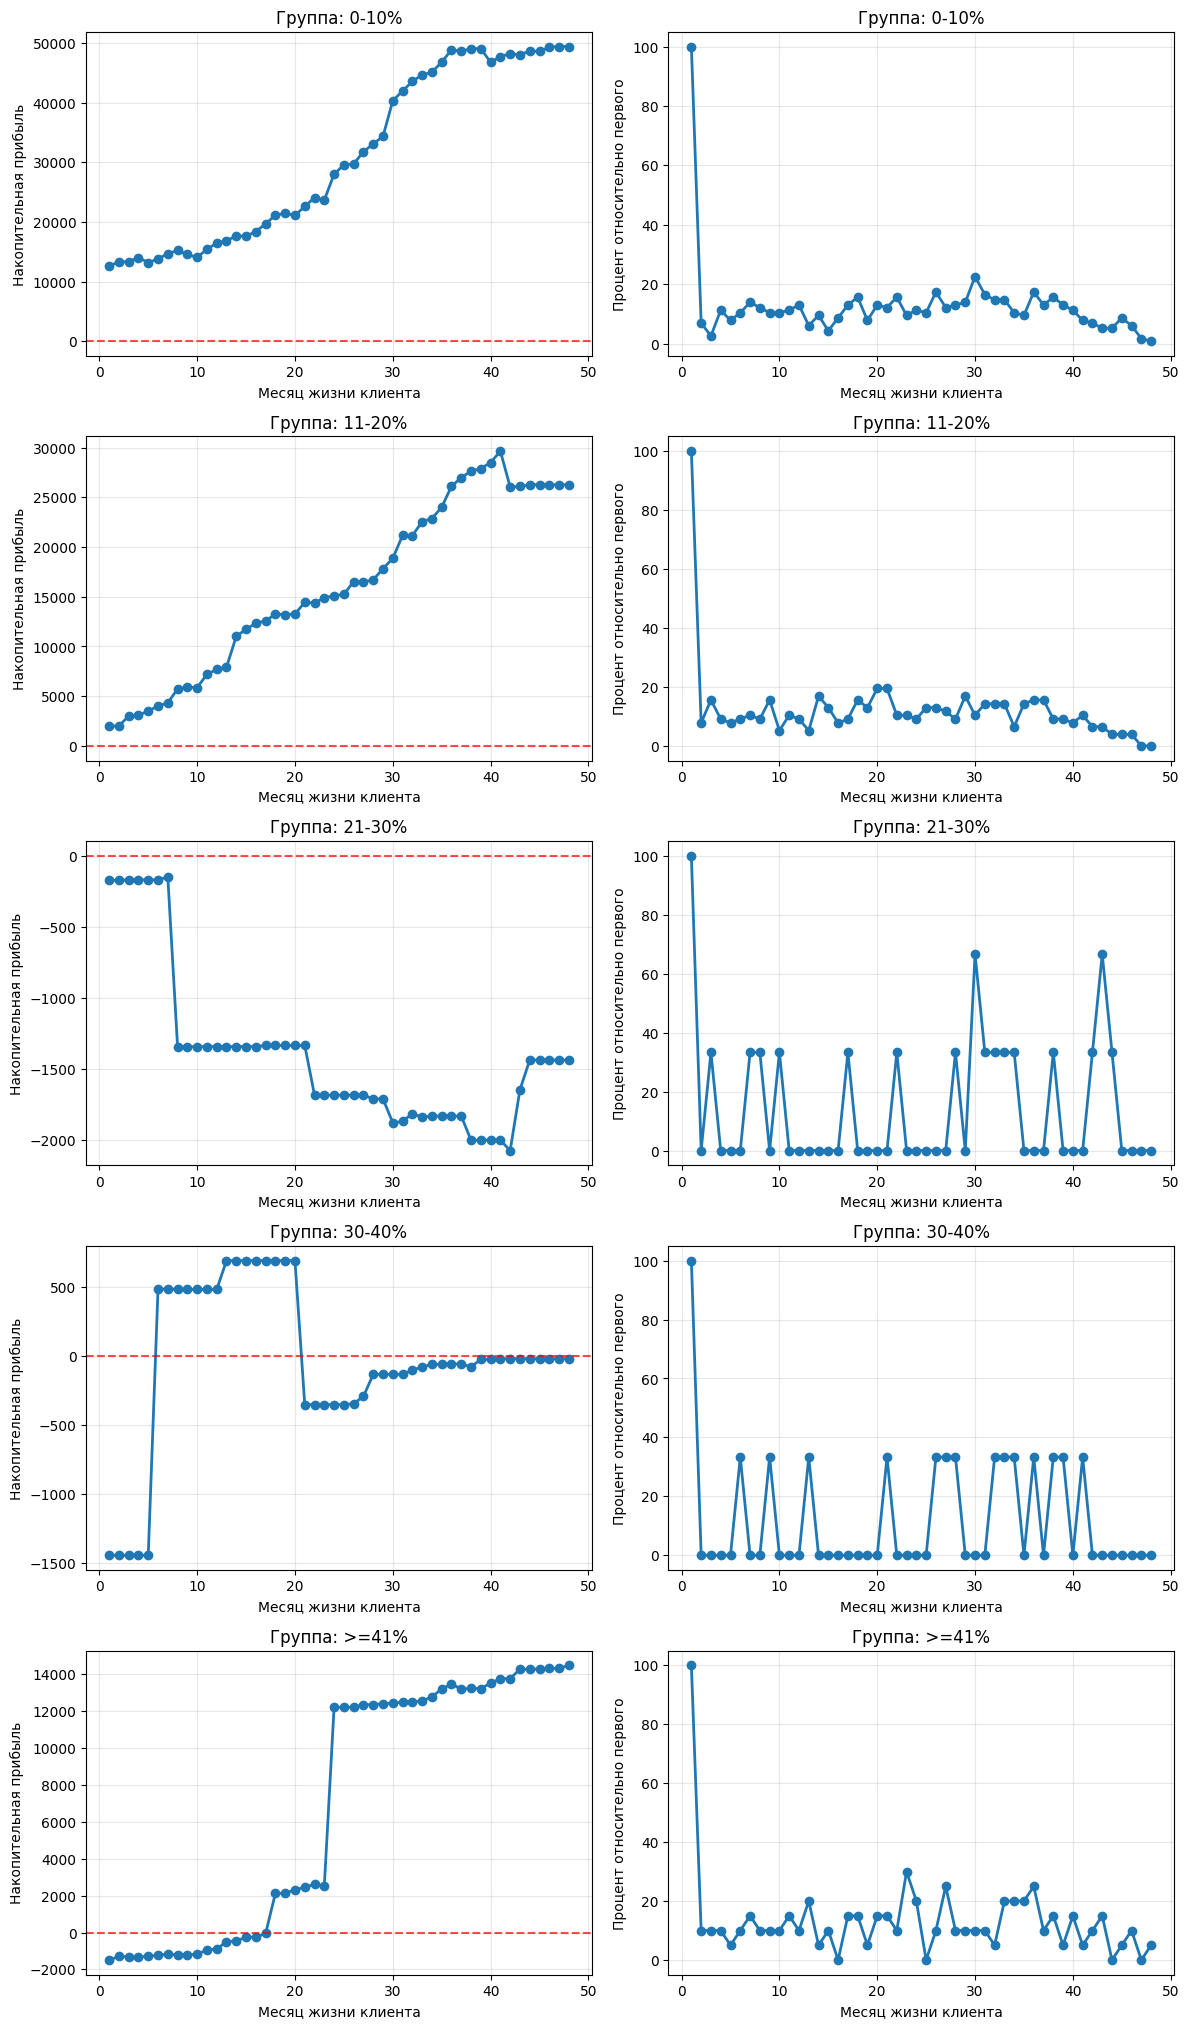

In [65]:
cohort_analysis_func(cohort_analysis_corp)

## Итоговые выводы по графику для корпораций
### Рекомендуется полностью убрать скидки 21-40%, так как они не выходят в итоговый плюс; Скидки >=41% окупаются к 17 месяцу жизни и затем стремительно поднимаются, но общая прибыль заметно ниже чем у скидок 0-20%, но эти скидки приемлемы, например: на праздники или на большие оптовые закупки, так как это устанавливает доверие с покупателем и приносит прибыль; Самую большую прибыль приносят скидки 0-10% и 11-20%, количество таких скидок нужно увеличить за счет 21-40%

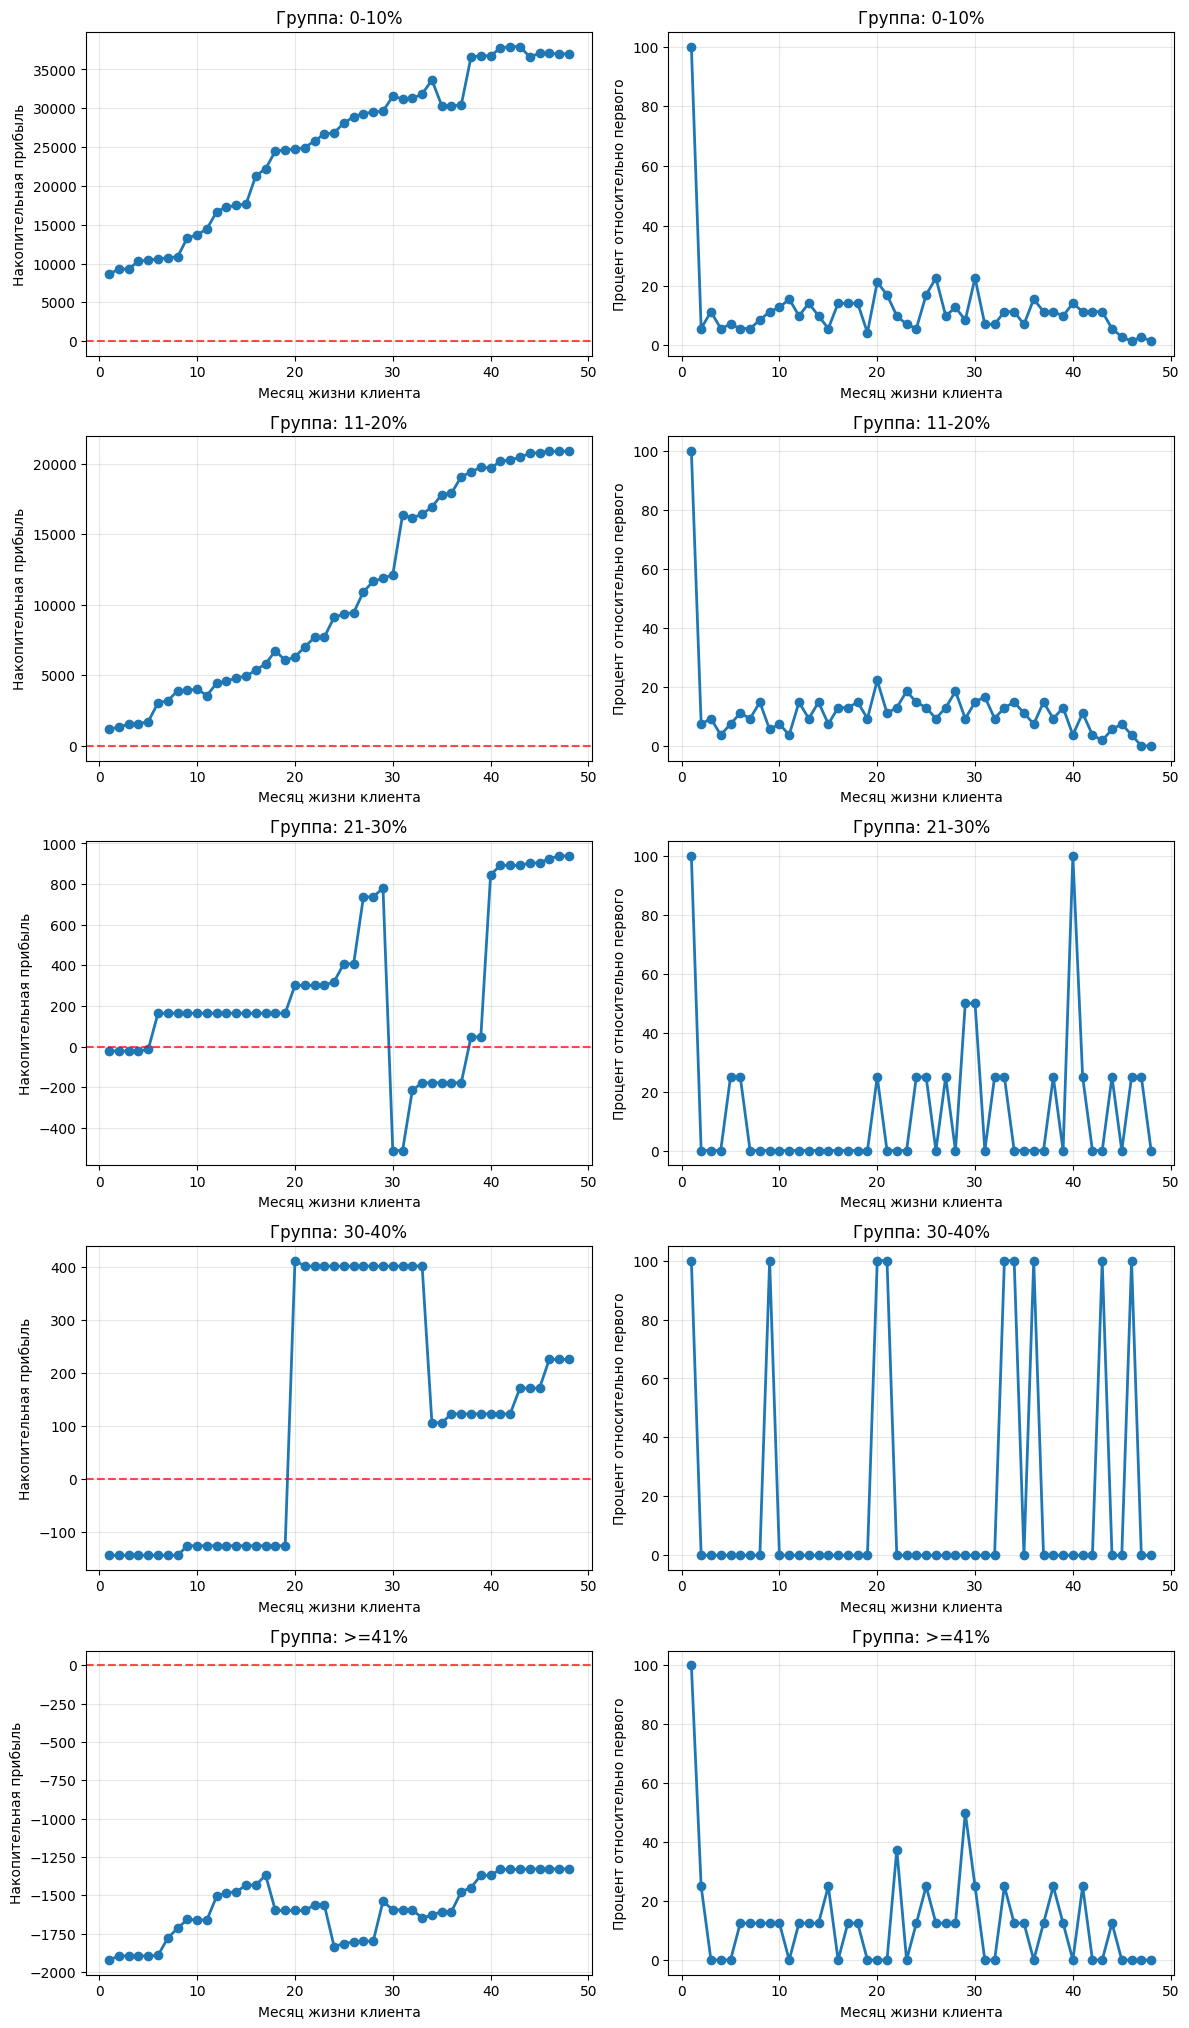

In [66]:
cohort_analysis_func(cohort_analysis_office)

## Итоги для категории домашний офис
### исключить скидки >=41% так как они даже не окупаются; группа скидок 21-40% приносят совсем незначительную прибыль, связанную с малым количеством клиентов, но тем не менее, эти клиенты довольно долго сотрудничают с нами, стоит попробовать увеличить количество таких скидок; Для группы скидок 0-10% есть незначительное падение на 35 месяце, связанное со скидками постоянным клиентам, но в целом эта группа приносит наибольшую прибыль для категории домашний офис и показывает удержание сравнимое с группой 11-20%, которая тоже положительно себя показывает 

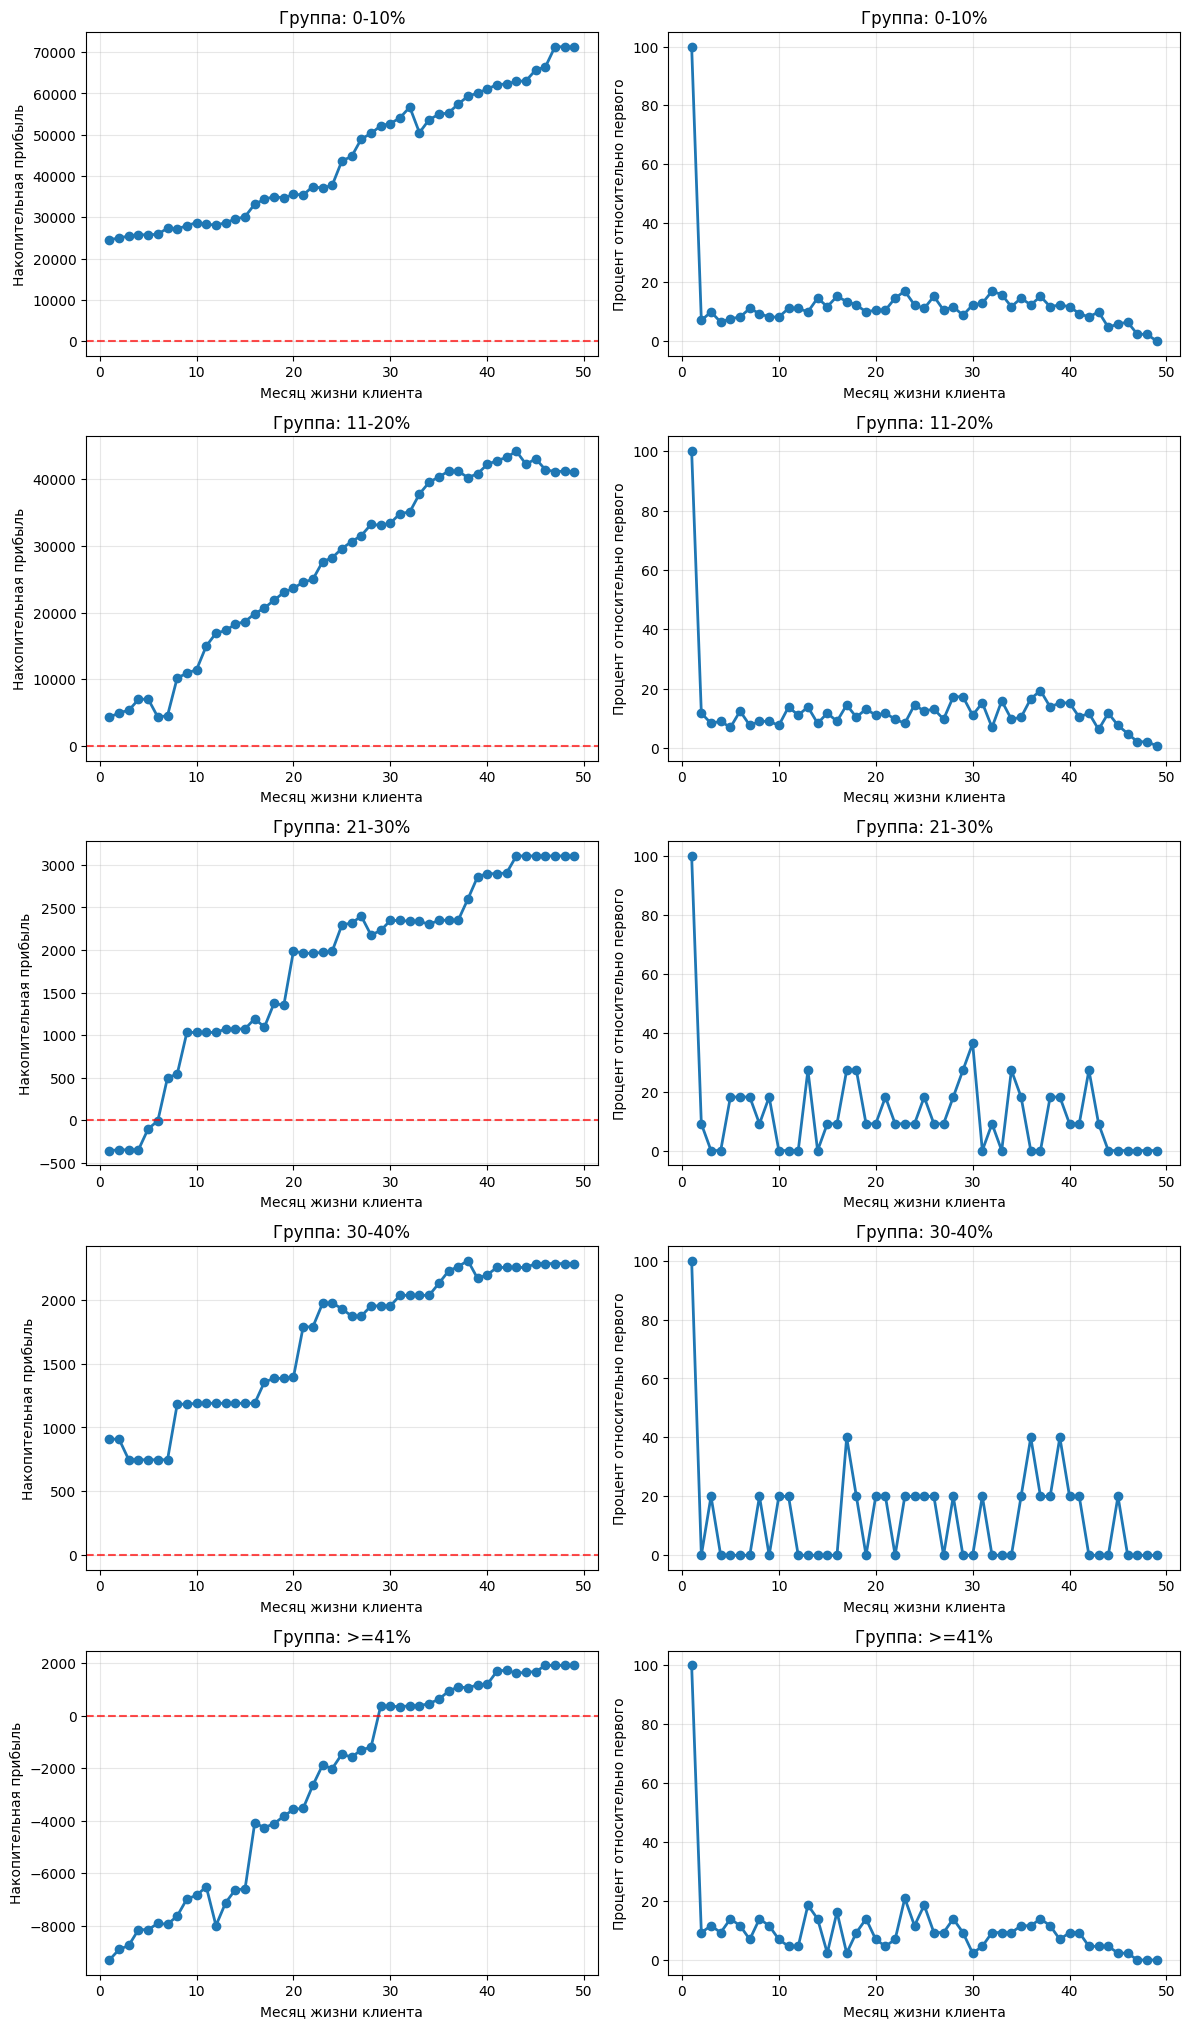

In [67]:
cohort_analysis_func(cohort_analysis_cons)

## Выводы для категории частных лиц
### Скидки на первый заказ >=41% плохо показывают себя на дистанции, они окупаются только на 29 месяц и не очень хорошо удерживают клиентов, а итоговая прибыль сравнимо маленькая относительно других групп, рекомендуется избегать; группы 21-40% показывают тоже значительно малую прибыль, связанную с малым количеством клиентов, но неплохо их удерживают, стоит попробовать увеличить количество таких скидок; скидки 0-20% показывают себя хорошо с точки зрения прибыли

# Выводы по проделанной работе

## Были обработаны и подготовлены данные к анализу, исследованы зависимости скидок с итоговой прибылью для каждой категории клиентов, предложены оптимальные скидки на первый заказ для каждой категории

## Дальнейший анализ предпологает оценить географическую связь с прибылью, также использовать в анализе параметры 'Ship Class' и проверить какие категории товаров могут негативно сказываться на показателях